In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("students.csv")

# 1. First 5 rows
# Using head() method to preview data in csv

print("===== First 5 Rows =====\n")
print(df.head())


# 2. Shape and Data Types

print("\n===== Shape =====")
print(df.shape)

print("\n===== Data Types =====")
print(df.dtypes)



# 3. Summary Statistics
# describe() shows summary of statistics across count, mean, min, max etc.,
print("\n===== Summary Statistics =====\n")
print(df.describe())



# 4. Pass/Fail Count
# Counting records with passed

print("\n===== Pass/Fail Count =====\n")
print(df['passed'].value_counts())



# 5. Average Score by Pass/Fail

subject_cols = ['math', 'science', 'english', 'history', 'pe']

print("\n===== Average Scores (Passed Students) =====\n")
print(df[df['passed'] == 1][subject_cols].mean())

print("\n===== Average Scores (Failed Students) =====\n")
print(df[df['passed'] == 0][subject_cols].mean())



# 6. Top Student (Highest Average)

df['average'] = df[subject_cols].mean(axis=1)

top_student = df.loc[df['average'].idxmax()]

print("\n===== Top Student =====\n")
print(f"Name: {top_student['name']}")
print(f"Average Score: {top_student['average']:.2f}")

===== First 5 Rows =====

      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

===== Shape =====
(15, 9)

===== Data Types =====
name                       str
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

===== Summary Statistics ===

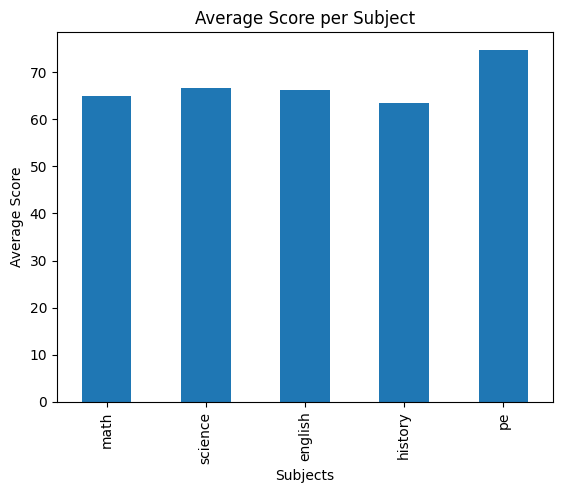

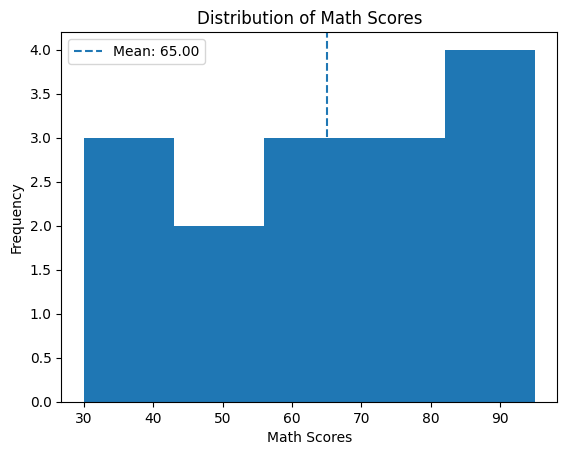

KeyboardInterrupt: 

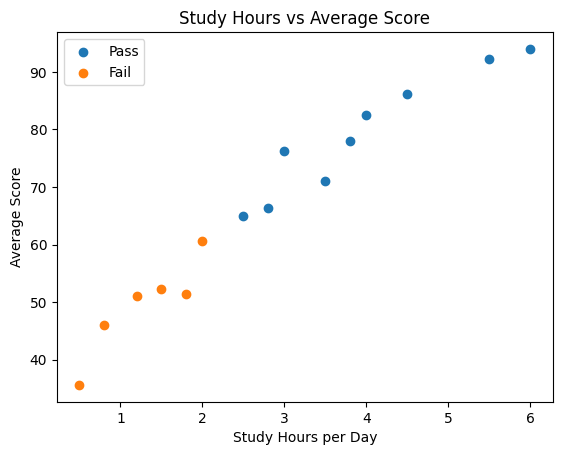

In [4]:
import pandas as pd
import matplotlib.pyplot as matlib_plot

# Loading dataset from local repository
df = pd.read_csv("students.csv")

# Add avg_score column
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

# -------------------------------
# 1. Bar Chart — Avg score per subject
# -------------------------------
# Creating a Bar chart using plot() method

avg_scores = df[subject_cols].mean()

matlib_plot.figure()
avg_scores.plot(kind='bar')

matlib_plot.title("Average Score per Subject")
matlib_plot.xlabel("Subjects")
matlib_plot.ylabel("Average Score")

matlib_plot.savefig("plot1_bar_chart.png")
matlib_plot.show()


# -------------------------------
# 2. Histogram — Math score distribution
# -------------------------------
matlib_plot.figure()

matlib_plot.hist(df['math'], bins=5)

mean_math = df['math'].mean()
matlib_plot.axvline(mean_math, linestyle='dashed', label=f"Mean: {mean_math:.2f}")

matlib_plot.title("Distribution of Math Scores")
matlib_plot.xlabel("Math Scores")
matlib_plot.ylabel("Frequency")
matlib_plot.legend()

matlib_plot.savefig("plot2_histogram.png")
matlib_plot.show()


# -------------------------------
# 3. Scatter Plot — Study hours vs Avg Score
# -------------------------------
matlib_plot.figure()

passed = df[df['passed'] == 1]
failed = df[df['passed'] == 0]

matlib_plot.scatter(passed['study_hours_per_day'], passed['avg_score'], label="Pass")
matlib_plot.scatter(failed['study_hours_per_day'], failed['avg_score'], label="Fail")

matlib_plot.title("Study Hours vs Average Score")
matlib_plot.xlabel("Study Hours per Day")
matlib_plot.ylabel("Average Score")
matlib_plot.legend()

matlib_plot.savefig("plot3_scatter_plot.png")
matlib_plot.show()


# -------------------------------
# 4. Box Plot — Attendance (Pass vs Fail)
# -------------------------------
matlib_plot.figure()

pass_attendance = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_attendance = df[df['passed'] == 0]['attendance_pct'].tolist()

matlib_plot.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])

matlib_plot.title("Attendance Distribution (Pass vs Fail)")
matlib_plot.ylabel("Attendance Percentage")

matlib_plot.savefig("plot4_boxplot.png")
matlib_plot.show()


# -------------------------------
# 5. Line Plot — Math vs Science scores
# -------------------------------
matlib_plot.figure()

matlib_plot.plot(df['name'], df['math'], marker='o', label="Math")
matlib_plot.plot(df['name'], df['science'], marker='x', label="Science")

matlib_plot.title("Math vs Science Scores by Student")
matlib_plot.xlabel("Student Name")
matlib_plot.ylabel("Score")
matlib_plot.xticks(rotation=45)
matlib_plot.legend()

matlib_plot.savefig("plot5_line.png")
matlib_plot.show()

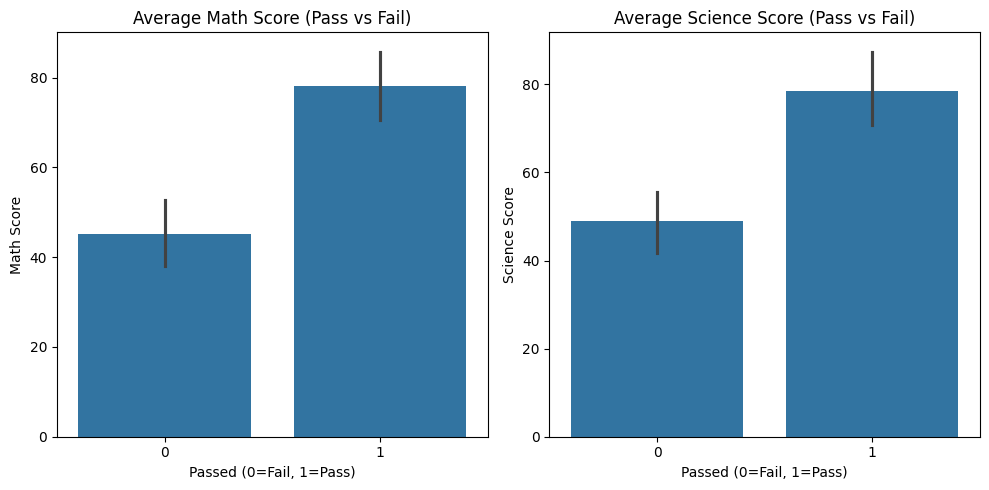

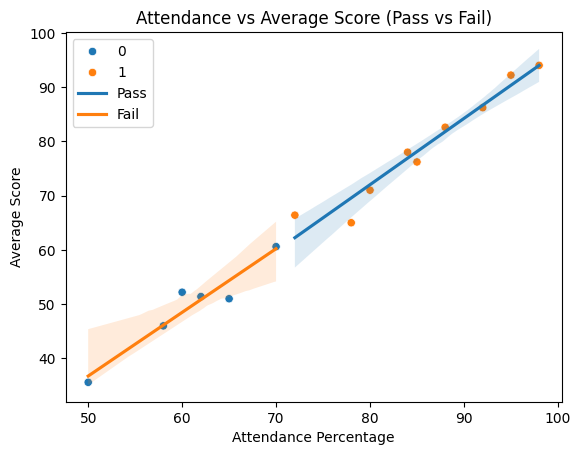

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as mat_plt_lib

# Load dataset
df = pd.read_csv("students.csv")

# Add avg_score column
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

# -------------------------------
# 1. Bar Plot — Avg Math & Science by Pass/Fail
# -------------------------------
mat_plt_lib.figure(figsize=(10, 5))

# Subplot 1 — Math
ax1 = mat_plt_lib.subplot(1, 2, 1)
sns.barplot(data=df, x='passed', y='math', ax=ax1)
ax1.set_title("Average Math Score (Pass vs Fail)")
ax1.set_xlabel("Passed (0=Fail, 1=Pass)")
ax1.set_ylabel("Math Score")

# Subplot 2 — Science
ax2 = mat_plt_lib.subplot(1, 2, 2)
sns.barplot(data=df, x='passed', y='science', ax=ax2)
ax2.set_title("Average Science Score (Pass vs Fail)")
ax2.set_xlabel("Passed (0=Fail, 1=Pass)")
ax2.set_ylabel("Science Score")

mat_plt_lib.tight_layout()
mat_plt_lib.savefig("seaborn_barplots.png")
mat_plt_lib.show()


# -------------------------------
# 2. Scatter Plot with Regression Lines
# -------------------------------
mat_plt_lib.figure()

# Scatter plot
sns.scatterplot(data=df, x='attendance_pct', y='avg_score', hue='passed')

# Regression lines (separate for Pass and Fail)
sns.regplot(
    data=df[df['passed'] == 1],
    x='attendance_pct',
    y='avg_score',
    label='Pass',
    scatter=False
)

sns.regplot(
    data=df[df['passed'] == 0],
    x='attendance_pct',
    y='avg_score',
    label='Fail',
    scatter=False
)

mat_plt_lib.title("Attendance vs Average Score (Pass vs Fail)")
mat_plt_lib.xlabel("Attendance Percentage")
mat_plt_lib.ylabel("Average Score")
mat_plt_lib.legend()

mat_plt_lib.savefig("seaborn_scatter_reg.png")
mat_plt_lib.show()


# -------------------------------
# 3. Comparison Comment
# -------------------------------

# Seaborn enables us to create more visually appealing plots with less code and more easy and optimized to use compared to mathlib
# especially for grouped comparisons (like pass vs fail).

Training Accuracy: 1.0

Test Accuracy: 1.0

===== Test Predictions =====

Jack — Actual: 0, Predicted: 0 → ✅ Correct
Liam — Actual: 0, Predicted: 0 → ✅ Correct
Alice — Actual: 1, Predicted: 1 → ✅ Correct

===== Feature Importance =====

english: 0.8125
attendance_pct: 0.5219
study_hours_per_day: 0.4844
pe: 0.4750
math: 0.4379
science: 0.3230
history: 0.2629


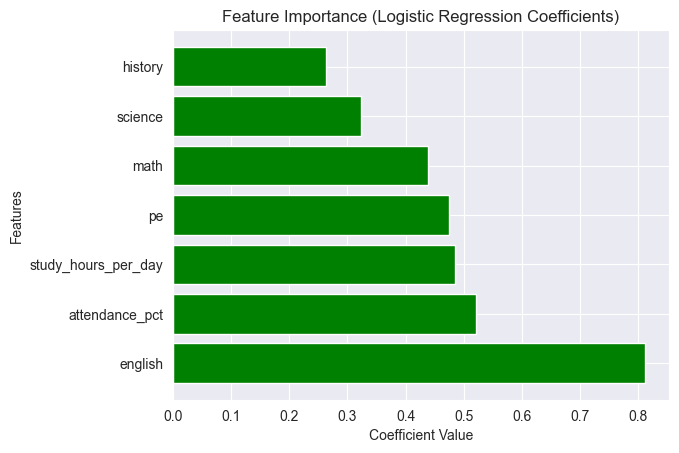


===== New Student Prediction =====

Prediction: Pass
Probability (Fail, Pass): [0.09203526 0.90796474]


C:\Users\AnkitSingh\OneDrive - Quadrafort Technologies Pvt. Ltd\Documents\Training\DE\Projects\todo_app\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [1]:
import pandas as pd
import matplotlib.pyplot as mat_plt_lib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# -------------------------------
# Load Data from local csv
# -------------------------------
df = pd.read_csv("students.csv")

# Features and Target
feature_cols = ['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']
X = df[feature_cols]
y = df['passed']

# -------------------------------
# Step 1 — Train/Test Split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -------------------------------
# Step 2 — Train Model
# -------------------------------
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Training Accuracy
train_preds = model.predict(X_train_scaled)
train_acc = accuracy_score(y_train, train_preds)

print("Training Accuracy:", train_acc)


# -------------------------------
# Step 3 — Evaluate Model
# -------------------------------
test_preds = model.predict(X_test_scaled)
test_acc = accuracy_score(y_test, test_preds)

print("\nTest Accuracy:", test_acc)

print("\n===== Test Predictions =====\n")

# Get student names from original df
test_names = df.loc[X_test.index, 'name']

for name, actual, pred in zip(test_names, y_test, test_preds):
    status = "✅ Correct" if actual == pred else "❌ Wrong"
    print(f"{name} — Actual: {actual}, Predicted: {pred} → {status}")


# -------------------------------
# Step 4 — Feature Importance
# -------------------------------
coefficients = model.coef_[0]

feature_importance = list(zip(feature_cols, coefficients))

# Sort by absolute value
feature_importance_sorted = sorted(
    feature_importance, key=lambda x: abs(x[1]), reverse=True
)

print("\n===== Feature Importance =====\n")
for feature, coef in feature_importance_sorted:
    print(f"{feature}: {coef:.4f}")


# Plot Feature Importance
features = [f[0] for f in feature_importance_sorted]
coefs = [f[1] for f in feature_importance_sorted]

colors = ['green' if c > 0 else 'red' for c in coefs]

mat_plt_lib.figure()
mat_plt_lib.barh(features, coefs, color=colors)

mat_plt_lib.title("Feature Importance (Logistic Regression Coefficients)")
mat_plt_lib.xlabel("Coefficient Value")
mat_plt_lib.ylabel("Features")

mat_plt_lib.savefig("feature_importance.png")
mat_plt_lib.show()


# -------------------------------
# Step 5 — Predict New Student
# -------------------------------
# For new student prediction we need to use previously learned scaling transformation based on which prediction & probability can be arrived as below
new_student = [[75, 70, 68, 65, 80, 82, 3.2]]

new_student_scaled = scaler.transform(new_student)

prediction = model.predict(new_student_scaled)[0]
probability = model.predict_proba(new_student_scaled)[0]

result = "Pass" if prediction == 1 else "Fail"

print("\n===== New Student Prediction =====\n")
print("Prediction:", result)
print(f"Probability (Fail, Pass): {probability}")